In [1]:
from sklearn.datasets import load_iris
import pandas as pd

# 加载数据
iris = load_iris()
X = iris.data
y = iris.target
df = pd.DataFrame(X, columns=iris.feature_names)
df['label'] = y

# 显示前五行
print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   label  
0      0  
1      0  
2      0  
3      0  
4      0  


G:\Anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


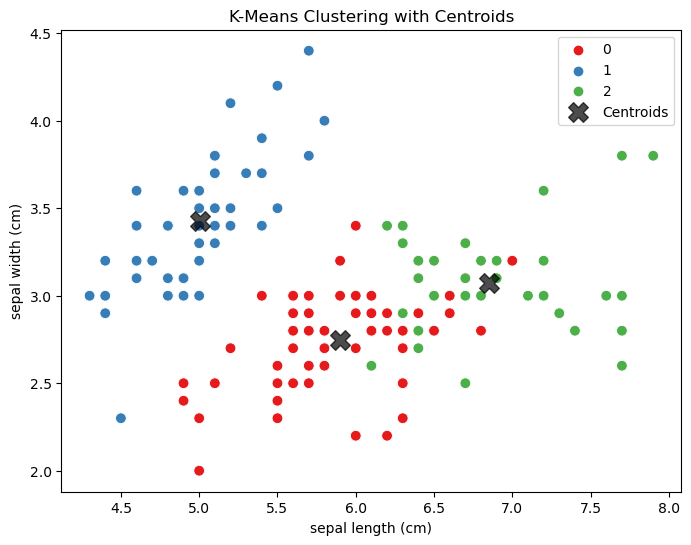

Cluster Centers:
 [[5.9016129  2.7483871  4.39354839 1.43387097]
 [5.006      3.428      1.462      0.246     ]
 [6.85       3.07368421 5.74210526 2.07105263]]


In [6]:
from sklearn.cluster import KMeans
import os
os.environ["OMP_NUM_THREADS"] = "1"
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 初始化模型
kmeans = KMeans(n_clusters=3,  n_init=10,random_state=42)
kmeans_labels = kmeans.fit_predict(X)

# 获取聚类中心
centers = kmeans.cluster_centers_

# 可视化
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=kmeans_labels, palette='Set1', s=60)
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=200, alpha=0.7, marker='X', label='Centroids')
plt.title("K-Means Clustering with Centroids")
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
plt.legend()
plt.show()
print("Cluster Centers:\n", centers)

聚类中心数量: 2
聚类中心坐标:
 [[6.21142857 2.89285714 4.85285714 1.67285714]
 [5.01632653 3.45102041 1.46530612 0.24489796]]


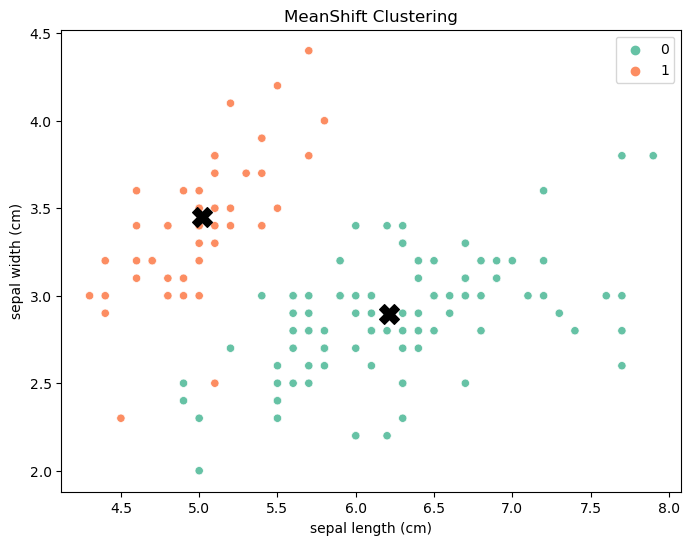

In [8]:
from sklearn.cluster import MeanShift

meanshift = MeanShift()
meanshift_labels = meanshift.fit_predict(X)

# 获取聚类中心
centers = meanshift.cluster_centers_

# 输出聚类中心数量
print("聚类中心数量:", len(centers))
print("聚类中心坐标:\n", centers)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=meanshift_labels, palette='Set2')
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=200, marker='X', label='Centroids')
plt.title("MeanShift Clustering")
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
plt.show()

聚类中心数量: 13
聚类中心坐标:
 [[4.9        3.305      1.455      0.2425    ]
 [5.43       3.92       1.49       0.26      ]
 [6.58571429 3.03571429 4.67142857 1.49285714]
 [5.63684211 2.66842105 4.10526316 1.26315789]
 [5.         2.3        3.275      1.025     ]
 [5.6        2.63333333 3.6        1.1       ]
 [5.9        3.05       4.5625     1.55      ]
 [6.12307692 2.59230769 4.87692308 1.63846154]
 [6.72352941 3.16470588 5.62352941 2.21176471]
 [6.41111111 2.82222222 5.52222222 1.86666667]
 [7.56666667 2.85       6.45       2.06666667]
 [7.6        3.73333333 6.4        2.23333333]
 [5.775      2.825      5.05       2.025     ]]


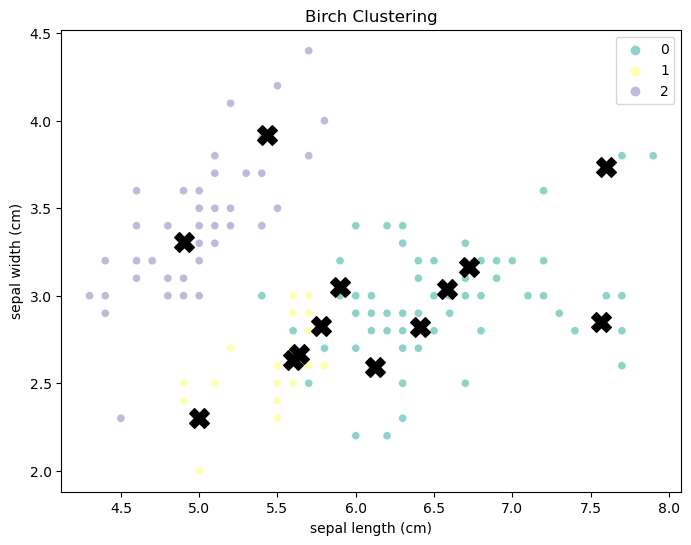

In [9]:
from sklearn.cluster import Birch

birch = Birch(n_clusters=3)
birch_labels = birch.fit_predict(X)
# 获取聚类中心
centers = birch.subcluster_centers_

print("聚类中心数量:", len(centers))
print("聚类中心坐标:\n", centers)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=birch_labels, palette='Set3')
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=200, marker='X', label='Centroids')
plt.title("Birch Clustering")
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
plt.show()

In [10]:
from sklearn.metrics import adjusted_rand_score

print("KMeans ARI：", adjusted_rand_score(y, kmeans_labels))
print("MeanShift ARI：", adjusted_rand_score(y, meanshift_labels))
print("Birch ARI：", adjusted_rand_score(y, birch_labels))


KMeans ARI： 0.7302382722834697
MeanShift ARI： 0.5583714437541352
Birch ARI： 0.6096252514698314
